In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set(style="whitegrid")

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

PATH_HITS_CSV = DATA_DIR / "ga_hits.csv"
PATH_SESSIONS_CSV = DATA_DIR / "ga_sessions.csv"

hits = pd.read_csv(PATH_HITS_CSV)
sessions = pd.read_csv(PATH_SESSIONS_CSV)

hits.head(), sessions.head()

C:\Users\Denlex\AppData\Local\Temp\ipykernel_18672\2480862364.py:18: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  sessions = pd.read_csv(PATH_SESSIONS_CSV)


(                                  session_id    hit_date  hit_time  \
 0  5639623078712724064.1640254056.1640254056  2021-12-23  597864.0   
 1  7750352294969115059.1640271109.1640271109  2021-12-23  597331.0   
 2   885342191847998240.1640235807.1640235807  2021-12-23  796252.0   
 3   142526202120934167.1640211014.1640211014  2021-12-23  934292.0   
 4  3450086108837475701.1640265078.1640265078  2021-12-23  768741.0   
 
    hit_number hit_type hit_referer  \
 0          30    event         NaN   
 1          41    event         NaN   
 2          49    event         NaN   
 3          46    event         NaN   
 4          79    event         NaN   
 
                                        hit_page_path event_category  \
 0  sberauto.com/cars?utm_source_initial=google&ut...           quiz   
 1  sberauto.com/cars/fiat?city=1&city=18&rental_c...           quiz   
 2  sberauto.com/cars/all/volkswagen/polo/e994838f...           quiz   
 3  sberauto.com/cars?utm_source_initial=yandex&

In [53]:
# Размеры таблиц
print("HITS shape:", hits.shape)
print("SESSIONS shape:", sessions.shape)

print("HITS info")
hits.info()

print("SESSIONS info")
sessions.info()

HITS shape: (15726470, 12)
SESSIONS shape: (1860042, 24)
HITS info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   hit_date        object 
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        object 
 5   hit_referer     object 
 6   hit_page_path   object 
 7   event_category  object 
 8   event_action    object 
 9   event_label     object 
 10  event_value     float64
 11  is_target_hit   int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 1.4+ GB
SESSIONS info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 24 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   session_id                object 
 1   client_id                 object 
 2   visit_date                object 
 3   visit_time             

На этом этапе проверяются размеры таблиц, типы признаков и общее качество исходных данных.  
`ga_hits` содержит события внутри сессий, а `ga_sessions` — характеристики самих визитов.

In [5]:
hits.head(3)
sessions.head(3)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk


In [41]:
# Для числовых столбцов
hits.describe().T.head(20)
sessions.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
visit_number,1860042.0,2.712804,11.829072,1.0,1.0,1.0,2.0,564.0
target,1860042.0,0.008543,0.092032,0.0,0.0,0.0,0.0,1.0
hits_count,1732266.0,9.054740,13.877267,1.0,1.0,4.0,11.0,768.0
unique_pages,1732266.0,1.862659,1.404235,1.0,1.0,1.0,2.0,45.0
events_count,1732266.0,9.054740,13.877267,1.0,1.0,4.0,11.0,768.0


In [42]:
# Для категориальных / object
hits.describe(include="object").T.head(20)
sessions.describe(include="object").T.head(20)

,count,unique,top,freq
session_id,1860042,1860042,9055430416266113553.1640968742.1640968742,1
client_id,1860042.0,1391717.0,1750498477.162945,462.0
visit_date,1860042,226,2021-05-24,39453
visit_time,1860042,85318,12:00:00,61067
utm_source,1859945,293,ZpYIoDJMcFzVoPFsHGJL,578290
utm_medium,1860042,56,banner,552272
utm_campaign,1640439,412,LTuZkdKfxRGVceoWkVyg,463481
utm_adcontent,1524427,286,JNHcPlZPxEMWDnRiyoBf,1006599
utm_keyword,777981,1219,puhZPIYqKXeFPaUviSjo,506819
device_category,1860042,3,mobile,1474871


## Структура признаков

Из первичного анализа видно, что в данных присутствуют:
- идентификаторы сессий и клиентов;
- маркетинговые признаки (`utm_*`);
- технические признаки устройства и браузера;
- географические признаки;
- временные характеристики визита.

In [7]:
# Пропустки
hits_missing = hits.isna().mean().sort_values(ascending=False)
sessions_missing = sessions.isna().mean().sort_values(ascending=False)

print("TOP 20 missing in HITS:")
hits_missing.head(20)

print("\nTOP 20 missing in SESSIONS:")
sessions_missing.head(20)

TOP 20 missing in HITS:

TOP 20 missing in SESSIONS:


device_model                0.991216
utm_keyword                 0.581740
device_os                   0.575330
device_brand                0.197403
utm_adcontent               0.180434
utm_campaign                0.118063
utm_source                  0.000052
session_id                  0.000000
client_id                   0.000000
visit_number                0.000000
utm_medium                  0.000000
visit_date                  0.000000
visit_time                  0.000000
device_category             0.000000
device_screen_resolution    0.000000
device_browser              0.000000
geo_country                 0.000000
geo_city                    0.000000
dtype: float64

### Вывод по первичному обзору данных

Таблица `ga_sessions` содержит информацию о пользовательских сессиях: дату и время визита, номер визита, источники трафика, utm-метки, параметры устройства и географию пользователя. Видно, что набор признаков включает как числовые, так и категориальные переменные, причём доля категориальных признаков достаточно велика.

На этапе первичного осмотра также заметно наличие пропусков в маркетинговых и device-признаках, что потребует аккуратной обработки при построении модели. Кроме того, часть категориальных полей имеет высокую кардинальность, например `utm_keyword`, `utm_campaign` и `geo_city`, поэтому при моделировании особенно важен корректный пайплайн предобработки.

In [43]:
hits["event_category"].value_counts(dropna=False).head(20)

event_category
card_web                     7456998
search_form                  2423605
sub_page_view                1986074
sub_button_click             1073471
listing_ads                  1040468
cars                          358915
sap_search_form               356596
quiz                          263134
auth                          189373
sap_search__form              188129
jivosite                       88443
chat                           85007
ad_banner                      40441
offers                         31218
navigation                     27075
footer                         20297
sub_submit                     18495
greenday_sub_button_click      15425
main_banners                   14142
profile_menu                   13879
Name: count, dtype: int64

In [44]:
hits["event_action"].value_counts(dropna=False).head(50)

event_action
view_card                             3558985
view_new_card                         3551009
sub_landing                           1798117
go_to_car_card                         973666
sub_view_cars_click                    791515
search_form_region                     512069
search_form_search_btn                 433748
sap_search_form_cost_to                356596
showed_number_ads                      326274
pagination_click                       248944
search_form_mark_select                222652
quiz_show                              214037
search_form_model_select               211890
sap_search_form_cost_from              188129
photos_all                             181493
search_form_search_car_type_select     174877
photos                                 158543
sub_car_page                           130310
view_more_click                        109971
search_kpp                              79465
sub_header_link_click                   79192
proactive invitation 

## Формирование целевой переменной

Целевым событием считается `sub_submit_success`.  
Если внутри сессии произошло хотя бы одно такое событие, всей сессии присваивается `target = 1`, иначе `target = 0`.

In [45]:
target_events = ["sub_submit_success"]

In [46]:
hits["is_target_hit"] = hits["event_action"].isin(target_events).astype(int)

hits["is_target_hit"].value_counts()
hits["is_target_hit"].mean()

np.float64(0.0011724818093316555)

C:\Users\Denlex\AppData\Local\Temp\ipykernel_18672\341893930.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette='Blues')


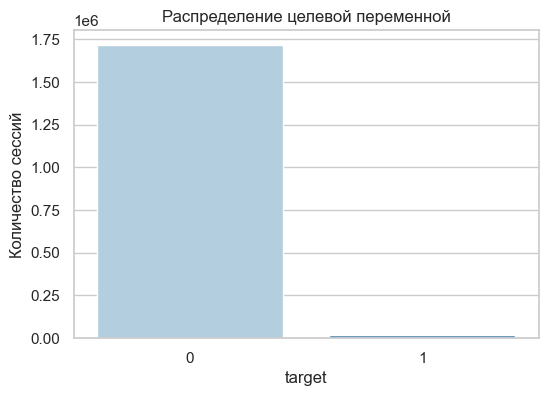

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

target_counts = session_target['target'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='Blues')
plt.title('Распределение целевой переменной')
plt.xlabel('target')
plt.ylabel('Количество сессий')
plt.xticks([0, 1], ['0', '1'])
plt.show()

In [47]:
session_target = (
    hits.groupby("session_id")["is_target_hit"]
        .max()  # если в сессии хотя бы один целевой хит → 1
        .reset_index()
        .rename(columns={"is_target_hit": "target"})
)

session_target["target"].value_counts(), session_target["target"].value_counts(normalize=True)

(target
 0    1718494
 1      16116
 Name: count, dtype: int64,
 target
 0    0.990709
 1    0.009291
 Name: proportion, dtype: float64)

In [50]:
target_rate = session_target['target'].mean()
print(f'Конверсия в целевое действие: {target_rate:.4%}')

Конверсия в целевое действие: 0.9291%


In [49]:
sessions = sessions.merge(session_target, on="session_id", how="left")

sessions["target"] = sessions["target"].fillna(0).astype(int)

sessions["target"].value_counts(), sessions["target"].value_counts(normalize=True)

(target
 0    1844152
 1      15890
 Name: count, dtype: int64,
 target
 0    0.991457
 1    0.008543
 Name: proportion, dtype: float64)

In [ ]:
# Доля целевых сессий (CR)
cr = sessions["target"].mean()
cr

np.float64(0.008542817850349617)

In [ ]:
# Проверка: у сессий с target=1 действительно есть целевой hit
sample_target_session = sessions.query("target == 1").sample(1, random_state=42)["session_id"].iloc[0]
hits[hits["session_id"] == sample_target_session]["event_action"].value_counts().head(20)

event_action
search_form_region                    14
view_new_card                          3
search_form_search_btn                 3
showed_number_ads                      3
view_card                              3
search_form_search_car_type_select     2
sub_car_claim_submit_click             1
sub_view_cars_click                    1
sub_submit_success                     1
sub_car_claim_click                    1
sub_landing                            1
go_to_car_card                         1
Name: count, dtype: int64

## Агрегация событий до уровня сессии

Так как целевая переменная определяется на уровне сессии, данные из `ga_hits` агрегируются по `session_id`.  
В качестве агрегированных признаков используются количество событий, количество уникальных страниц и общее число действий в сессии.

In [ ]:
agg_hits = (
    hits.groupby("session_id")
        .agg(
            hits_count=("hit_number", "count"),
            unique_pages=("hit_page_path", "nunique"),
            events_count=("event_action", lambda x: x.notna().sum())
        )
        .reset_index()
)

agg_hits.head()

,session_id,hits_count,unique_pages,events_count
0,1000009318903347362.1632663668.1632663668,10,3,10
1,1000010177899156286.1635013443.1635013443,6,2,6
2,1000013386240115915.1635402956.1635402956,11,3,11
3,1000017303238376207.1623489300.1623489300,12,3,12
4,1000020580299877109.1624943350.1624943350,1,1,1


In [ ]:
sessions = sessions.merge(agg_hits, on="session_id", how="left")

sessions[["hits_count", "unique_pages", "events_count"]].describe()

,hits_count,unique_pages,events_count
count,1.732266e+06,1.732266e+06,1.732266e+06
mean,9.054740e+00,1.862659e+00,9.054740e+00
std,1.387727e+01,1.404235e+00,1.387727e+01
min,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00,1.000000e+00
50%,4.000000e+00,1.000000e+00,4.000000e+00
75%,1.100000e+01,2.000000e+00,1.100000e+01
max,7.680000e+02,4.500000e+01,7.680000e+02


### Вывод по агрегированным признакам поведения

После агрегации событий до уровня сессии были получены поведенческие признаки `hits_count`, `unique_pages` и `events_count`. Эти признаки отражают интенсивность и глубину взаимодействия пользователя с сайтом и потенциально должны быть полезны для прогнозирования конверсии.

По описательной статистике видно, что распределения имеют выраженную правостороннюю асимметрию: медианные значения заметно ниже средних, а максимумы существенно превышают типичные наблюдения. Это означает, что большинство сессий короткие, но существует небольшая доля очень активных пользователей с большим количеством действий.

In [ ]:
sessions.groupby("target")[["hits_count", "unique_pages", "events_count"]].mean()

,hits_count,unique_pages,events_count
target,,,
0,8.866953,1.849318,8.866953
1,29.338829,3.303713,29.338829


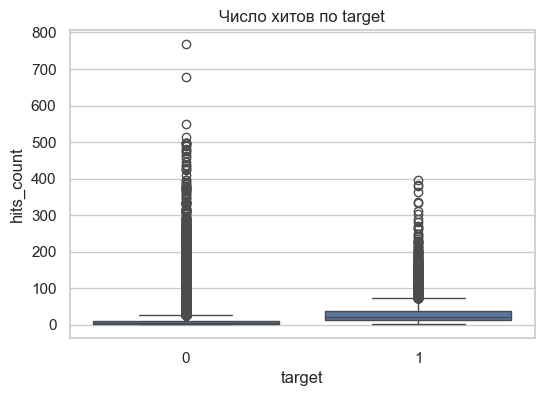

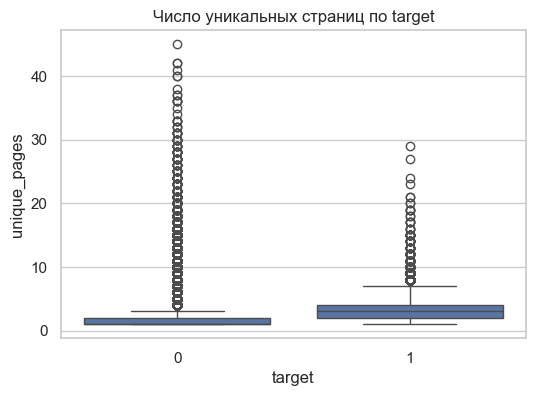

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.boxplot(data=sessions, x="target", y="hits_count")
plt.title("Число хитов по target")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=sessions, x="target", y="unique_pages")
plt.title("Число уникальных страниц по target")
plt.show()

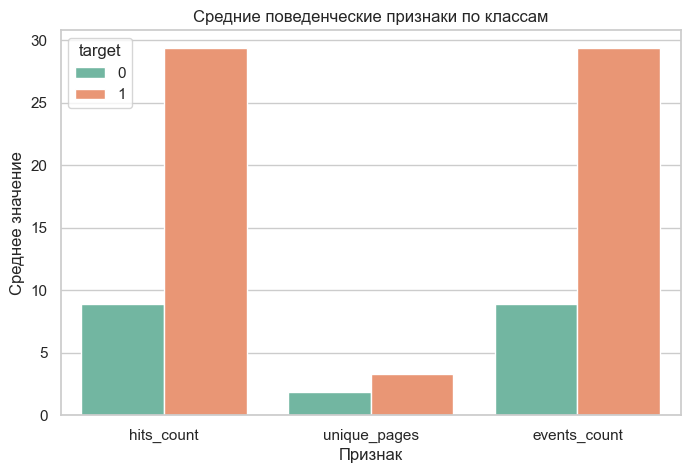

In [55]:
behavior_by_target = sessions.groupby('target')[['hits_count', 'unique_pages', 'events_count']].mean().reset_index()
behavior_long = behavior_by_target.melt(id_vars='target', var_name='feature', value_name='mean_value')

plt.figure(figsize=(8, 5))
sns.barplot(data=behavior_long, x='feature', y='mean_value', hue='target', palette='Set2')
plt.title('Средние поведенческие признаки по классам')
plt.xlabel('Признак')
plt.ylabel('Среднее значение')
plt.show()

### Вывод по связи поведения пользователя с конверсией

Сравнение средних значений по классам показывает явное различие между конвертирующими и неконвертирующими сессиями. Для целевого класса среднее количество хитов, событий и уникальных страниц значительно выше, чем для нецелевого.

Это указывает на то, что конверсия тесно связана с глубиной вовлечения пользователя: чем активнее пользователь взаимодействует с сайтом, тем выше вероятность совершения целевого действия. Следовательно, поведенческие признаки должны играть ключевую роль в модели.

## Анализ категориальных признаков

На этом этапе исследуется связь между конверсией и ключевыми категориальными признаками:
- источником трафика;
- типом канала;
- категорией устройства;
- городом пользователя.

In [ ]:
cr_by_source = (
    sessions
    .groupby("utm_source")["target"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
    .head(20)
)

cr_by_source["mean"] = cr_by_source["mean"].round(4)
cr_by_source

,count,mean
utm_source,,
ZpYIoDJMcFzVoPFsHGJL,578290,0.0104
fDLlAcSmythWSCVMvqvL,300575,0.0096
kjsLglQLzykiRbcDiGcD,266354,0.0073
MvfHsxITijuriZxsqZqt,186199,0.0007
BHcvLfOaCWvWTykYqHVe,116320,0.0121
bByPQxmDaMXgpHeypKSM,102287,0.0155
QxAxdyPLuQMEcrdZWdWb,51415,0.0123
aXQzDWsJuGXeBXexNHjc,31152,0.0173
jaSOmLICuBzCFqHfBdRg,29241,0.0046


C:\Users\Denlex\AppData\Local\Temp\ipykernel_18672\1505033287.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


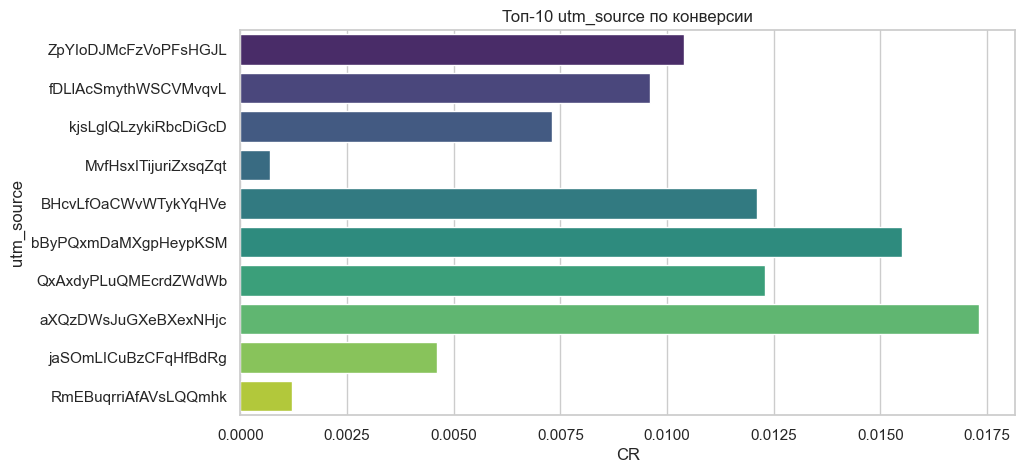

In [57]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=cr_by_source.head(10)['mean'],
    y=cr_by_source.head(10).index,
    palette='viridis'
)
plt.title('Топ-10 utm_source по конверсии')
plt.xlabel('CR')
plt.ylabel('utm_source')
plt.show()

### Вывод по источникам трафика

Конверсия заметно различается между источниками трафика. При этом среди наиболее массовых источников есть как каналы с относительно высокой конверсией, так и источники с очень низкой эффективностью.

Это означает, что `utm_source` действительно несёт полезную информацию для модели и может использоваться не только для прогноза, но и для маркетинговой интерпретации результатов. На практике такой анализ помогает выделить более качественные каналы привлечения пользователей.

In [ ]:
cr_by_medium = (
    sessions
    .groupby("utm_medium")["target"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
)

cr_by_medium["mean"] = cr_by_medium["mean"].round(4)
cr_by_medium.head(20)

,count,mean
utm_medium,,
banner,552272,0.0102
cpc,434794,0.0078
(none),300575,0.0096
cpm,242083,0.0009
referral,152050,0.0153
organic,63034,0.0085
email,29240,0.0046
push,28035,0.0133
stories,10582,0.0014


C:\Users\Denlex\AppData\Local\Temp\ipykernel_18672\671369470.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


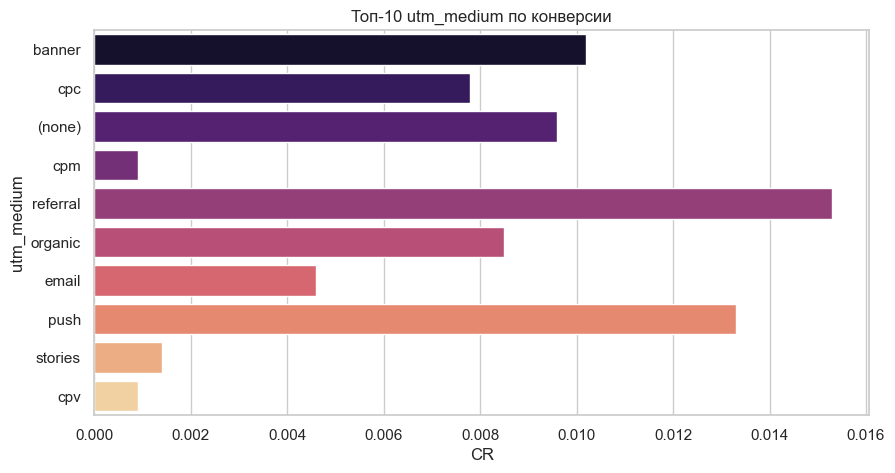

In [58]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=cr_by_medium.head(10)['mean'],
    y=cr_by_medium.head(10).index,
    palette='magma'
)
plt.title('Топ-10 utm_medium по конверсии')
plt.xlabel('CR')
plt.ylabel('utm_medium')
plt.show()

### Вывод по каналам привлечения

Анализ `utm_medium` показывает, что каналы привлечения существенно отличаются по вероятности конверсии. Например, массовые каналы вроде `banner` и `cpc` дают умеренную конверсию, тогда как отдельные каналы демонстрируют либо значительно более высокий, либо почти нулевой результат.

Следовательно, тип канала привлечения является важным фактором качества трафика. Этот признак стоит сохранить в модели, а с точки зрения бизнеса он полезен для оценки эффективности рекламных кампаний и перераспределения маркетингового бюджета.

In [ ]:
cr_by_device = (
    sessions
    .groupby("device_category")["target"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
)

cr_by_device["mean"] = cr_by_device["mean"].round(4)
cr_by_device

,count,mean
device_category,,
mobile,1474871,0.0084
desktop,366863,0.0092
tablet,18308,0.0062


C:\Users\Denlex\AppData\Local\Temp\ipykernel_18672\2805632805.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


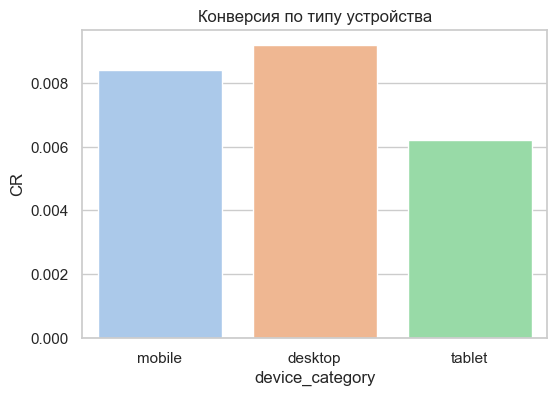

In [59]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x=cr_by_device.index,
    y=cr_by_device['mean'],
    palette='pastel'
)
plt.title('Конверсия по типу устройства')
plt.xlabel('device_category')
plt.ylabel('CR')
plt.show()

### Вывод по типу устройства

Наибольшая доля сессий приходится на мобильные устройства, что говорит о доминировании mobile-трафика в данных. При этом различия в конверсии между mobile, desktop и tablet есть, но они выражены слабее, чем различия по поведенческим и маркетинговым признакам.

Это позволяет предположить, что тип устройства влияет на целевое действие, но не является главным драйвером конверсии. Скорее всего, этот признак будет играть вспомогательную роль в модели.

In [ ]:
cr_by_city = (
    sessions
    .groupby("geo_city")["target"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
    .head(20)
)

cr_by_city["mean"] = cr_by_city["mean"].round(4)
cr_by_city

,count,mean
geo_city,,
Moscow,805329,0.0095
Saint Petersburg,296788,0.0070
(not set),78172,0.0060
Yekaterinburg,35788,0.0076
Krasnodar,32243,0.0121
Kazan,29531,0.0134
Samara,24992,0.0096
Nizhny Novgorod,22227,0.0071
Ufa,21679,0.0108


C:\Users\Denlex\AppData\Local\Temp\ipykernel_18672\3642341864.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


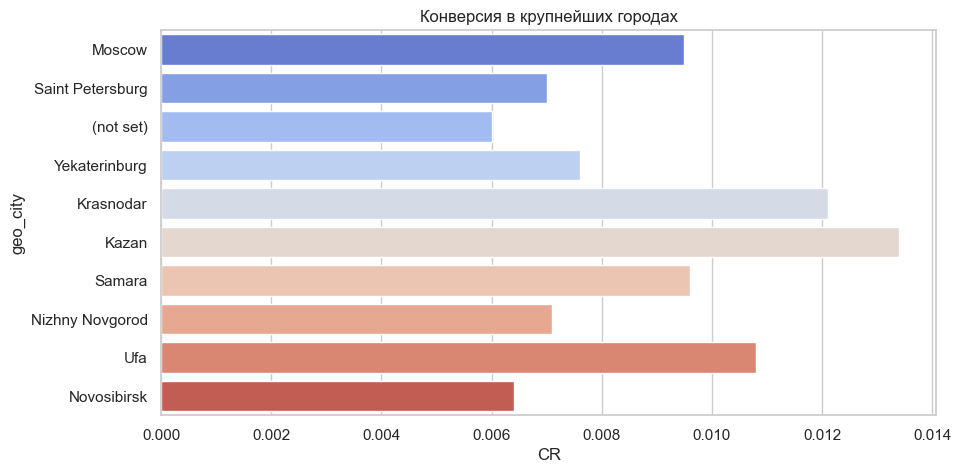

In [60]:
top_cities = cr_by_city.sort_values('count', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_cities['mean'],
    y=top_cities.index,
    palette='coolwarm'
)
plt.title('Конверсия в крупнейших городах')
plt.xlabel('CR')
plt.ylabel('geo_city')
plt.show()

### Вывод по географии

Конверсия различается между городами, причём даже среди крупных городов нет полностью однородного поведения пользователей. Москва даёт наибольший объём трафика, однако не всегда показывает максимальный уровень конверсии по сравнению с другими крупными городами.

Это говорит о том, что географический фактор может влиять на поведение и склонность к конверсии. Признак `geo_city` имеет смысл сохранять в модель, особенно с учётом его дальнейшей важности в интерпретации.

In [ ]:
# Список фичей
num_features = ["hits_count", "unique_pages", "events_count", "visit_number"]
cat_features = [
    "utm_source", "utm_medium", "utm_campaign", "utm_adcontent", "utm_keyword",
    "device_category", "device_os", "device_brand", "device_browser",
    "geo_country", "geo_city"
]

features = num_features + cat_features
target_col = "target"

df_model = sessions[features + [target_col]].copy()

df_model.shape, df_model[target_col].mean()

((1860042, 16), np.float64(0.008542817850349617))

In [ ]:
# Формируем датафрейм для модели
from sklearn.model_selection import train_test_split

num_features = ["hits_count", "unique_pages", "events_count", "visit_number"]
cat_features = [
    "utm_source", "utm_medium", "utm_campaign", "utm_adcontent", "utm_keyword",
    "device_category", "device_os", "device_brand", "device_browser",
    "geo_country", "geo_city"
]

target_col = "target"

df_model = sessions[num_features + cat_features + [target_col]].copy()

df_model.shape, df_model[target_col].mean()

((1860042, 16), np.float64(0.008542817850349617))

In [ ]:
X = df_model[num_features + cat_features]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

y_train.mean(), y_test.mean()

(np.float64(0.00854282129495784), np.float64(0.008542804071944497))

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

# Пайплайн для числовых признаков
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Пайплайн для категориальных признаков
categorical_transformer_sparse = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",  # по умолчанию sparse_output=True / sparse=True
        ))
    ]
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessor_sparse = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer_sparse, cat_features),
    ]
)

clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor_sparse),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            n_jobs=-1,
        ))
    ]
)

## Baseline-модель: LogisticRegression

В качестве базовой модели используется логистическая регрессия.  
Она нужна как интерпретируемый и быстрый baseline, с которым далее сравнивается более сильная бустинговая модель

In [ ]:
# Логрег
clf.fit(X_train, y_train)
y_train_proba = clf.predict_proba(X_train)[:, 1]
y_test_proba = clf.predict_proba(X_test)[:, 1]

roc_auc_train = roc_auc_score(y_train, y_train_proba)
roc_auc_test = roc_auc_score(y_test, y_test_proba)

roc_auc_train, roc_auc_test

(0.8823826483301294, 0.8656227266942773)

In [ ]:
#Урезаем категориальные фичи для бустинга
def top_n_categories(series, n=50, other_name="other"):
    top = series.value_counts().index[:n]
    return series.where(series.isin(top), other_name)

df_gb = df_model.copy()

for col in ["utm_source", "utm_campaign", "geo_city"]:
    df_gb[col] = top_n_categories(df_gb[col], n=50)


In [ ]:
#Отдельный dense‑препроцессор для бустинга

num_features = ["hits_count", "unique_pages", "events_count", "visit_number"]
cat_features = [
    "utm_source", "utm_medium", "utm_campaign", "utm_adcontent", "utm_keyword",
    "device_category", "device_os", "device_brand", "device_browser",
    "geo_country", "geo_city"
]

X_gb = df_gb[num_features + cat_features]
y_gb = df_gb[target_col]

X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_gb,
    y_gb,
    test_size=0.2,
    random_state=42,
    stratify=y_gb
)

categorical_transformer_dense = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer_dense, cat_features),
    ]
)

## Основная модель: HistGradientBoosting

Для повышения качества используется `HistGradientBoostingClassifier`.  
Эта модель лучше улавливает нелинейные зависимости и взаимодействия между признаками, чем линейный baseline.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor_dense),
        ("classifier", HistGradientBoostingClassifier(
            learning_rate=0.1,
            max_depth=None,
            max_iter=200,
            min_samples_leaf=50,
            random_state=42
        ))
    ]
)

gb_clf.fit(X_train_gb, y_train_gb)

y_train_proba_gb = gb_clf.predict_proba(X_train_gb)[:, 1]
y_test_proba_gb = gb_clf.predict_proba(X_test_gb)[:, 1]

roc_auc_train_gb = roc_auc_score(y_train_gb, y_train_proba_gb)
roc_auc_test_gb = roc_auc_score(y_test_gb, y_test_proba_gb)

roc_auc_train_gb, roc_auc_test_gb

(0.9214385137614423, 0.9168295127138879)

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "model": ["LogisticRegression", "HistGradientBoosting"],
    "roc_auc_train": [roc_auc_train, roc_auc_train_gb],
    "roc_auc_test": [roc_auc_test, roc_auc_test_gb],
})
results

,model,roc_auc_train,roc_auc_test
0,LogisticRegression,0.882383,0.865623
1,HistGradientBoosting,0.921439,0.916830


C:\Users\Denlex\AppData\Local\Temp\ipykernel_18672\4230740161.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='model', y='roc_auc_test', palette='Set1')


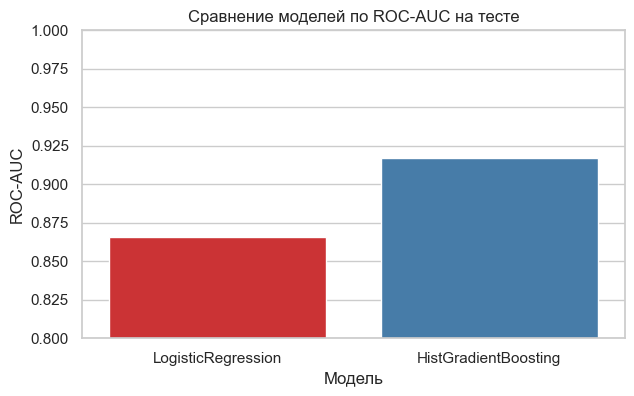

In [61]:
plt.figure(figsize=(7, 4))
sns.barplot(data=results, x='model', y='roc_auc_test', palette='Set1')
plt.title('Сравнение моделей по ROC-AUC на тесте')
plt.xlabel('Модель')
plt.ylabel('ROC-AUC')
plt.ylim(0.8, 1.0)
plt.show()

In [51]:
best_model_name = results.sort_values('roc_auc_test', ascending=False).iloc[0]['model']
best_score = results['roc_auc_test'].max()
print(f'Лучшая модель: {best_model_name}, ROC-AUC test = {best_score:.4f}')

Лучшая модель: HistGradientBoosting, ROC-AUC test = 0.9168


### Вывод по сравнению моделей

Были протестированы две модели: логистическая регрессия и HistGradientBoostingClassifier. Обе модели показали хорошее качество по метрике ROC-AUC, однако градиентный бустинг продемонстрировал лучший результат как на обучающей, так и на тестовой выборке.

Разница между ROC-AUC на train и test для HistGradientBoostingClassifier остаётся умеренной, что говорит о хорошем качестве обобщения и отсутствии критического переобучения. Поэтому именно эта модель была выбрана в качестве финальной.

## Интерпретация модели

Для оценки вклада признаков используется permutation importance.  
Этот метод показывает, насколько падает качество модели при случайном перемешивании конкретного признака.

In [ ]:
from sklearn.inspection import permutation_importance

# Берём подвыборку теста для importance
X_test_sample, _, y_test_sample, _ = train_test_split(
    X_test_gb,
    y_test_gb,
    test_size=0.85,      # оставим ~15% 
    random_state=42,
    stratify=y_test_gb
)

X_test_sample.shape, y_test_sample.mean()

((55801, 15), np.float64(0.008548233902618232))

In [ ]:
result = permutation_importance(
    gb_clf,
    X_test_sample,
    y_test_sample,
    n_repeats=3,         
    random_state=42,
    n_jobs=1,            # без распараллеливания, меньше пиков по памяти
    scoring="roc_auc"
)

perm_importance = pd.DataFrame({
    "feature": X_test_sample.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_importance.head(20)

,feature,importance_mean,importance_std
0,hits_count,0.422163,0.005520
1,unique_pages,0.032467,0.002636
6,utm_campaign,0.015366,0.000952
3,visit_number,0.014425,0.001512
4,utm_source,0.009160,0.000462
7,utm_adcontent,0.006227,0.000651
14,geo_city,0.005366,0.000551
10,device_os,0.003304,0.000019
8,utm_keyword,0.002176,0.000572
12,device_browser,0.002144,0.000102


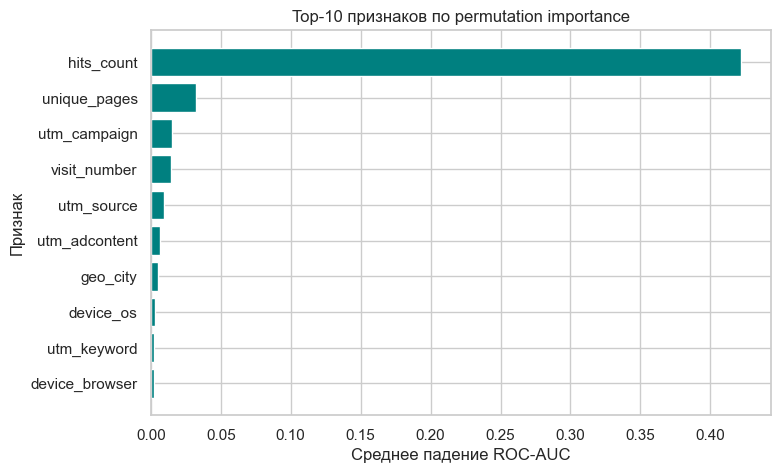

In [62]:
top_features = perm_importance.head(10).sort_values('importance_mean')

plt.figure(figsize=(8, 5))
plt.barh(top_features['feature'], top_features['importance_mean'], color='teal')
plt.title('Top-10 признаков по permutation importance')
plt.xlabel('Среднее падение ROC-AUC')
plt.ylabel('Признак')
plt.show()

### Вывод по важности признаков

Наиболее важным признаком оказался `hits_count`, что подтверждает ранее выявленную сильную связь между глубиной взаимодействия пользователя с сайтом и вероятностью конверсии. Также существенный вклад вносят `unique_pages`, `visit_number`, `utm_campaign`, `utm_source`, `utm_adcontent` и `geo_city`.

Таким образом, итоговая модель в первую очередь опирается на поведенческие характеристики сессии, а затем — на маркетинговые и географические признаки. Это делает модель не только качественной с точки зрения ROC-AUC, но и интерпретируемой с точки зрения бизнес-логики.

## Сохранение модели

После обучения финальная модель сохраняется в файл `model_histgb.pkl` для дальнейшего использования в скрипте предсказания и в API.

In [ ]:
from pathlib import Path
import joblib

BASE_DIR = Path.cwd().parent
MODELS_DIR = BASE_DIR / "models"

MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(gb_clf, MODELS_DIR / "model_histgb.pkl")

['c:\\IDE\\хаккатон\\models\\model_histgb.pkl']

In [ ]:
num_features = ["hits_count", "unique_pages", "events_count", "visit_number"]
cat_features = [
    "utm_source", "utm_medium", "utm_campaign", "utm_adcontent", "utm_keyword",
    "device_category", "device_os", "device_brand", "device_browser",
    "geo_country", "geo_city"
]

## Общий вывод

В ходе работы были объединены данные по сессиям и событиям пользователей, сформирована целевая переменная и построены признаки уровня сессии. Исследовательский анализ показал, что на вероятность конверсии сильнее всего влияют поведенческие характеристики пользователя, а также источник и канал трафика.

Среди протестированных моделей наилучшее качество показал HistGradientBoostingClassifier, достигший наивысшего значения ROC-AUC на тестовой выборке. Анализ важности признаков подтвердил, что модель опирается прежде всего на глубину взаимодействия с сайтом, а затем на маркетинговые и географические характеристики.

Полученная модель может использоваться для оценки вероятности совершения целевого действия, анализа качества трафика и поддержки решений по оптимизации рекламных кампаний и пользовательского пути на сайте.